# Example 7: Agent-Assisted LAS Packet Walkthrough

This notebook is the detailed end-user recipe for building an open-hole
packet one step at a time through the public `wellplot.agent` API.

Unlike the YAML-first user notebooks, this one is credentialed and manual:

- it uses a live hosted model through `wellplot.agent`
- it runs the local `wellplot-mcp` server under the hood
- it starts from a tiny starter logfile and revises the same draft in steps
- it shows a preview image after each major authoring cell

What you will do:

1. point the draft at your own LAS file
2. generate the first-page header and add remarks
3. add one track at a time
4. preview the evolving section after each step
5. render the final PDF through the public agent session helper

Prerequisites:

- `python -m pip install "wellplot[agent,las,notebook]"`
- one supported OpenAI credential source under the repository or job root:
  `OPENAI_API_KEY`, `.env.local`, `.env`, `OPENAI_API_KEY.txt`, or
  `openai_api_key.txt`
- run the notebook from a checkout of this repository so the example data and
  workspace folders are available

This notebook is intentionally unexecuted in git because it depends on a live
model, local credentials, and your chosen LAS file.


In [1]:
import sys
from pathlib import Path

try:
    import wellplot
except ImportError as exc:
    raise RuntimeError(
        "Install the published 'wellplot' package in the active "
        "environment before running this notebook."
    ) from exc

# Walk upward from the current working directory until we find the
# repository checkout that holds the example sources and sample data.
cwd = Path.cwd().resolve()
REPO_ROOT = next((path for path in (cwd, *cwd.parents) if (path / "examples").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError(
        "Run this notebook from a checkout of the wellplot repository "
        "so the example files and sample data are available."
    )

EXAMPLES_DIR = REPO_ROOT / "examples"
WORKSPACE_DIR = REPO_ROOT / "workspace"
WORKSPACE_RENDERS = WORKSPACE_DIR / "renders"
WORKSPACE_RENDERS.mkdir(parents=True, exist_ok=True)

examples_path = str(EXAMPLES_DIR)
if examples_path not in sys.path:
    sys.path.insert(0, examples_path)

print("wellplot version:", wellplot.__version__)
print("Examples root:", EXAMPLES_DIR)
print("Render output:", WORKSPACE_RENDERS)

wellplot version: 0.3.0
Examples root: /home/user/projects/well_log_os/examples
Render output: /home/user/projects/well_log_os/workspace/renders


In [2]:
import os

from wellplot.agent import (
    create_project_session,
    display_authoring_result,
    relative_path,
)

MODEL = os.getenv("OPENAI_MODEL", "gpt-5.4")
PROJECT_DIR = REPO_ROOT / "workspace" / "tutorials" / "agent_las_step_by_step"
session, paths = create_project_session(
    server_root=REPO_ROOT,
    project_dir=PROJECT_DIR,
    model=MODEL,
)
session.configure_rounds(run_max_rounds=12, revise_max_rounds=18)
SAMPLE_LAS_PATH = REPO_ROOT / "workspace" / "data" / "30-23a-3 8117_d.las"

print("Model:", MODEL)
print("Project folder:", relative_path(paths.project_dir, root=REPO_ROOT))
print("Sample LAS source:", relative_path(SAMPLE_LAS_PATH, root=REPO_ROOT))

Model: gpt-5.4
Project folder: workspace/tutorials/agent_las_step_by_step
Sample LAS source: workspace/data/30-23a-3 8117_d.las


## 1. Create A Starter Scaffold

This cell uses `session.bootstrap_starter(...)` to stage the data source, configure the default draft/render paths, and write a reusable base template plus one small starter logfile under the project folder. The preset keeps the visual system and report chrome in the template, while the starter logfile holds only the draft-specific section, track, and seed binding state.


In [3]:
starter = session.bootstrap_starter(
    kind="open_hole_quicklook",
    source_data_file=SAMPLE_LAS_PATH,
    staged_data_name="user_input.las",
    draft_logfile="agent_open_hole_draft.log.yaml",
    render_output_path="agent_open_hole_draft.pdf",
    starter_logfile="agent_starter.log.yaml",
    title="Main Review",
    subtitle="Placeholder starter source",
    depth_range=(8400, 9300),
    starter_name="Agent LAS Starter",
)
USER_LAS_PATH = starter.data_file
STARTER_TEMPLATE = starter.template_path
STARTER_LOGFILE = starter.logfile_path
DRAFT_LOGFILE = session.draft_logfile
FINAL_PDF = session.render_output_path

# Optional: replace the staged file with your own LAS before continuing.
# starter = session.bootstrap_starter(
#     kind="open_hole_quicklook",
#     source_data_file="/absolute/path/to/your.las",
#     staged_data_name="user_input.las",
#     draft_logfile="agent_open_hole_draft.log.yaml",
#     render_output_path="agent_open_hole_draft.pdf",
#     starter_logfile="agent_starter.log.yaml",
#     title="Main Review",
#     subtitle="Placeholder starter source",
#     depth_range=(8400, 9300),
#     overwrite_data=True,
# )

print("User LAS path:", relative_path(USER_LAS_PATH, root=REPO_ROOT))
print("Draft logfile:", relative_path(DRAFT_LOGFILE, root=REPO_ROOT))
print("Final PDF:", relative_path(FINAL_PDF, root=REPO_ROOT))
starter.display_yaml()

User LAS path: workspace/tutorials/agent_las_step_by_step/user_input.las
Draft logfile: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Final PDF: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.pdf


render:
  backend: matplotlib
  dpi: 144
  continuous_strip_page_height_mm: 297
  matplotlib:
    style:
      report:
        summary_label_fontsize: 8.0
        summary_value_fontsize: 10.5
        provider_fontsize: 16.0
        service_fontsize: 8.0
        tail_service_fontsize: 8.0
        field_label_fontsize: 7.0
        field_value_fontsize: 7.8
        detail_header_fontsize: 9.0
        detail_label_fontsize: 6.4
        detail_value_fontsize: 6.4
        tail_frame_y: 0.74
        tail_frame_height: 0.22
      section_title:
        background_color: '#0d3fb3'
        border_mode: box
        border_color: '#0d3fb3'
        border_linewidth: 0.8
        padding_left: 0.03
        padding_right: 0.03
        title_align: center
        subtitle_align: center
        title_fontsize: 11.0
        subtitle_fontsize: 6.6
        title_color: '#ffffff'
        subtitle_color: '#eaf0ff'
        title_y: 0.68
        subtitle_y: 0.22
      track_header:
        background_color: '#eef2f8'
      track:
        x_tick_labelsize: 6.0
      grid:
        depth_major_linewidth: 0.65
document:
  page:
    size: A4
    orientation: portrait
    continuous: false
    bottom_track_header_enabled: true
    margin_left_mm: 0
    margin_right_mm: 8
    margin_top_mm: 0
    margin_bottom_mm: 0
    track_gap_mm: 0
    header_height_mm: 0
    track_header_height_mm: 30
    footer_height_mm: 0
  depth:
    unit: ft
    scale: 240
    major_step: 10
    minor_step: 2
  layout:
    heading:
      enabled: true
      provider_name: Company
      general_fields:
      - key: archive_no
        label: Archive No.
        value: ''
      - key: api_no
        label: API No.
        value: ''
      - key: version
        label: Version
        value: ''
      - key: company
        label: Company
        source_key: COMP
      - key: well
        label: Well
        source_key: WELL
      - key: field
        label: Field
        source_key: FLD
      - key: county
        label: County
        source_key: CNTY
      - key: country
        label: Country
        source_key: CTRY
      - key: location
        label: Location
        source_key: LOC
      - key: section
        label: Section
        value: ''
      - key: township
        label: Township
        value: ''
      - key: range
        label: Range
        value: ''
      - key: footage
        label: Footage
        value: ''
      - key: latitude
        label: Latitude
        source_key: LATI
      - key: longitude
        label: Longitude
        source_key: LONG
      - key: logging_date
        label: Logging Date
        source_key: DATE
      - key: scale
        label: Scale
        value: ft 1:240
      - key: measured_from
        label: Measured From
        value: ''
      - key: log_measured_from
        label: Log Measured From
        source_key: LMF
      - key: perforation_measured_from
        label: Perforation Measured From
        value: ''
      - key: elevation_kb
        label: KB
        source_key: EKB
      - key: elevation_gl
        label: GL
        source_key: EGL
      - key: elevation_df
        label: DF
        source_key: EDF
      - key: top_log_interval
        label: Top Log Interval
        source_key: STRT
      - key: bottom_log_interval
        label: Bottom Log Interval
        source_key: STOP
      - key: fluid_type
        label: Fluid Type
        value: ''
      - key: service_company
        label: Service Company
        source_key: SRVC
      service_titles:
      - value: Open Hole Quicklook
        alignment: center
        bold: true
      - value: ''
        alignment: center
      - value: ''
        alignment: center
      detail:
        kind: open_hole
        title: Open Hole Metadata
        rows:
        - label: Date
          values:
          - source_key: DATE
          - ''
        - label_cells:
          - Run
          - Direction
          columns:
          - cells:
            - ''
          - cells:
        

template:
  path: base.template.yaml
version: 1
name: Agent LAS Starter
render:
  output_path: agent_open_hole_draft.pdf
document:
  layout:
    log_sections:
    - id: main
      title: Main Review
      subtitle: Placeholder starter source
      data:
        source_path: user_input.las
        source_format: las
      tracks:
      - id: gr_sp
        title: GR/SP
        kind: normal
        width_mm: 32
        position: 1
      - id: depth
        title: Depth
        kind: reference
        width_mm: 18
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 100
          secondary_grid:
            display: true
            line_count: 4
      depth_range:
      - 8400
      - 9300
  bindings:
    on_missing: skip
    channels:
    - channel: GR
      track_id: gr_sp
      kind: curve
      label: GR
      style:
        color: '#2e7d32'

## 2. Create The Initial Draft

The first natural-language request clones the starter, keeps the deterministic open-hole header scaffold, fills any values it can from the LAS metadata, and keeps only the seeded overview track plus the depth track while the packet is still sparse.


Initial draft
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Done:
 - No structural changes detected.
Next help:
 - I can help with the next draft revision or render the final PDF.
Tool trace: ['summarize_logfile_draft', 'inspect_authoring_vocab', 'inspect_heading_slots', 'preview_header_mapping', 'update_track', 'update_track', 'apply_header_values', 'inspect_data_source', 'set_section_data_source', 'set_heading_content', 'parse_key_value_text', 'apply_header_values', 'apply_header_values', 'apply_header_values']


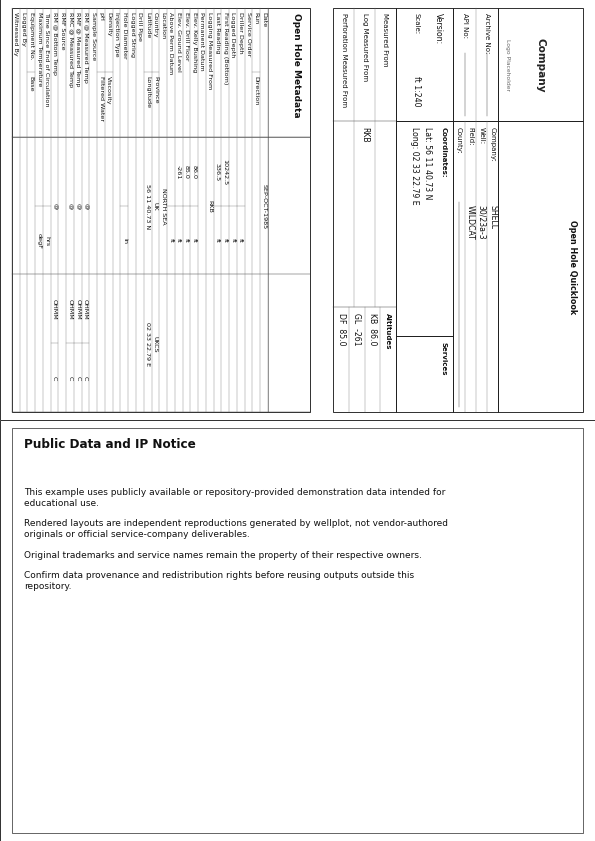

In [4]:
seed_result = await session.run(
    goal=f"""
        Start from the existing starter logfile and create the initial open-hole draft.

        - Keep the section id `main`.
        - Set the section subtitle to `Interactive LAS tutorial draft`.
        - Keep the seeded `gr_sp` overview track before the depth track.
        - Do not add any additional tracks yet.
        - Keep the existing open-hole header archetype structure.
        - Fill any available header values from the LAS metadata.
        - If some open-hole header labels do not have values yet, keep the blank placeholders.
        - Set the first service title to `Open Hole Quicklook`.
        - Do not add remarks yet.
    """,
    source_logfile_path=STARTER_LOGFILE,
)

display_authoring_result("Initial draft", seed_result, preview="report")

Initial draft
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Done:
 - Heading content changed.
 - Filled `RMF @ Measured Temp`.
 - Filled `RMC @ Measured Temp`.
Why not:
 - Ambiguous header key. Use an explicit prefixed key.
Next help:
 - I can inspect the remaining header slots or preview a more explicit mapping for any skipped values.
Tool trace: ['inspect_heading_slots', 'parse_key_value_text', 'preview_header_mapping', 'apply_header_values']


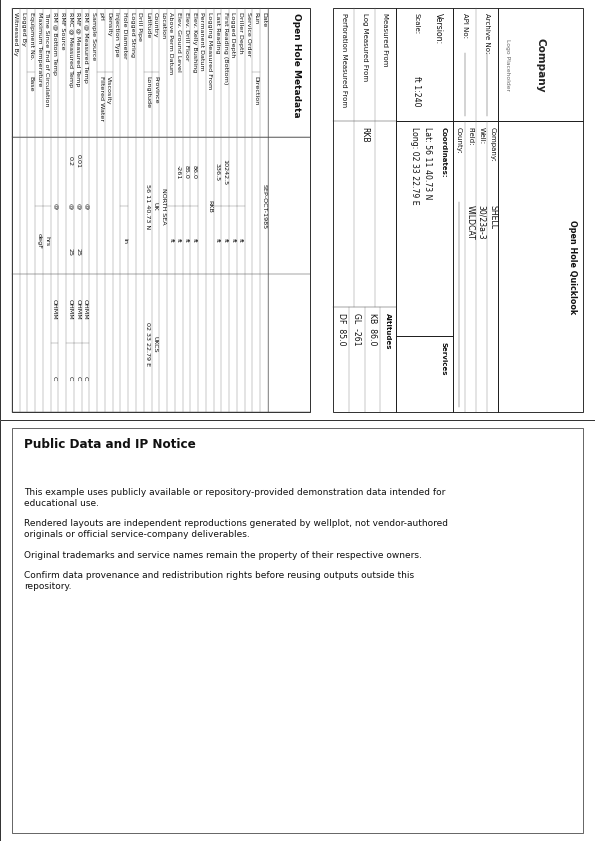

In [5]:
seed_result = await session.run(
    goal=f"""
        Fill the following header fields with the following values:
        - Rmf: 0.01 @ 25
        - Rmc: 0.2 @ 25
        - Rm: 0.005 @ 35
        
    """,
    source_logfile_path=STARTER_LOGFILE,
)

display_authoring_result("Initial draft", seed_result, preview="report")

Remarks added
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Done:
 - Heading content changed.
 - Filled `service_title_1`.
 - Filled `service_title_2`.
 - Filled `service_title_3`.
 - Filled `company`.
 - Filled `well`.
 - Filled `field`.
 - Filled `county`.
 - Filled `country`.
 - Filled `section`.
 - Filled `township`.
 - Filled `range`.
 - Filled `footage`.
 - Filled `latitude`.
 - Filled `Latitude`.
 - Filled `longitude`.
 - Filled `Longitude`.
 - Filled `elevation_kb`.
 - Filled `Elev. Kelly Bushing`.
 - Filled `elevation_gl`.
 - Filled `Elev. Ground Level`.
 - Filled `elevation_df`.
 - Filled `Elev. Drill Floor`.
 - Filled `log_measured_from`.
 - Filled `Logging Measured From`.
 - Filled `measured_from`.
 - Filled `Above Perm Datum`.
 - Filled `logging_date`.
 - Filled `Run`.
 - Filled `Driller Depth`.
 - Filled `Logged Depth`.
 - Filled `bottom_log_interval`.
 - Filled `top_log_interval`.
 - Filled `fluid_type`.
 - Filled `Density`.
 - Filled `

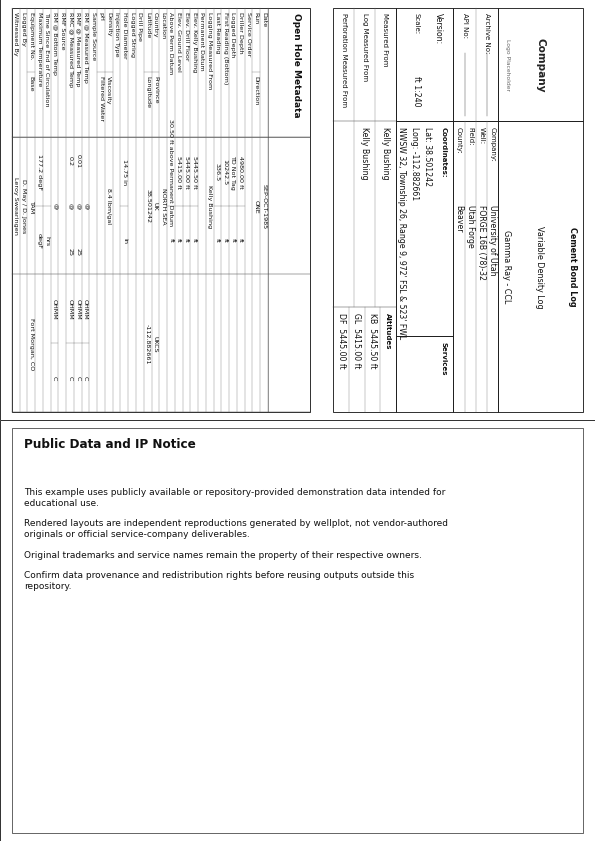

In [6]:
complete_header = await session.revise(
    feedback="""
        Use the following values to complete the relevant header fields:

            FORGE 16B (78)-32 — Header Information Consolidated

            LOG / SERVICE
            - Cement Bond Log
            - Variable Density Log
            - Gamma Ray - CCL

            COMPANY / WELL IDENTIFICATION
            - Company: University of Utah
            - Well: FORGE 16B (78)-32
            - Field: Utah Forge
            - County: Beaver
            - State: Utah

            LOCATION
            - Section: NWSW 32
            - Township: 26
            - Range: 9
            - Footage: 972' FSL & 523' FWL
            - Latitude: 38.501242
            - Longitude: -112.882661

            ELEVATION / DATUM
            - K.B.: 5445.50 ft
            - G.L.: 5415.00 ft
            - D.F.: 5445.00 ft
            - Log Measured From: Kelly Bushing
            - Drilling Measured From: Kelly Bushing
            - Ground Level Elevation: 5415.00 ft
            - Kelly Bushing: 30.50 ft above Permanent Datum

            WELL / LOGGING DETAILS
            - Logging Date: 08-May-2023
            - Run Number: ONE
            - Depth Driller: 4980.00 ft
            - Schlumberger Depth: TD Not Tag
            - Bottom Log Interval: 4845.00 ft
            - Top Log Interval: 25.00 ft
            - Casing Fluid Type: Fresh Water
            - Casing Fluid Density: not listed
            - Density: 8.4 lbm/gal
            - Fluid Level: 8.00 ft

            BIT / CASING / TUBING STRING
            - Bit Size: 14.75 in
            - Bit Interval From: 100.00 ft
            - Bit Interval To: 4980.00 ft
            - Casing/Tubing Size: 11.75 in
            - Casing/Tubing Weight: 65.00 lbm/ft
            - Casing/Tubing Grade: N/A
            - Casing/Tubing Interval From: 0.00 ft
            - Casing/Tubing Interval To: 4839.00 ft

            TEMPERATURE / UNIT / PERSONNEL
            - Max Recorded Temperature: 177.2 degF
            - Logged on Bottom: 08-May-2023
            - Time: 12:30:00
            - Unit Number: TAM
            - Unit Location: Fort Morgan, CO
            - Recorded By: D. May / D. Jones
            - Witnessed By: Leroy Swearingen
    """,
)

display_authoring_result("Remarks added", complete_header, preview="report")

## 3. Add The Remarks Block

Revise the same draft with one short remarks block that explains what the packet is for and keeps the public-data framing concise.


Remarks added
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Done:
 - Remarks content changed.
Next help:
 - I can help with the next draft revision or render the final PDF.
Tool trace: ['summarize_logfile_draft', 'set_remarks_content', 'inspect_authoring_vocab', 'inspect_heading_slots', 'set_remarks_content']


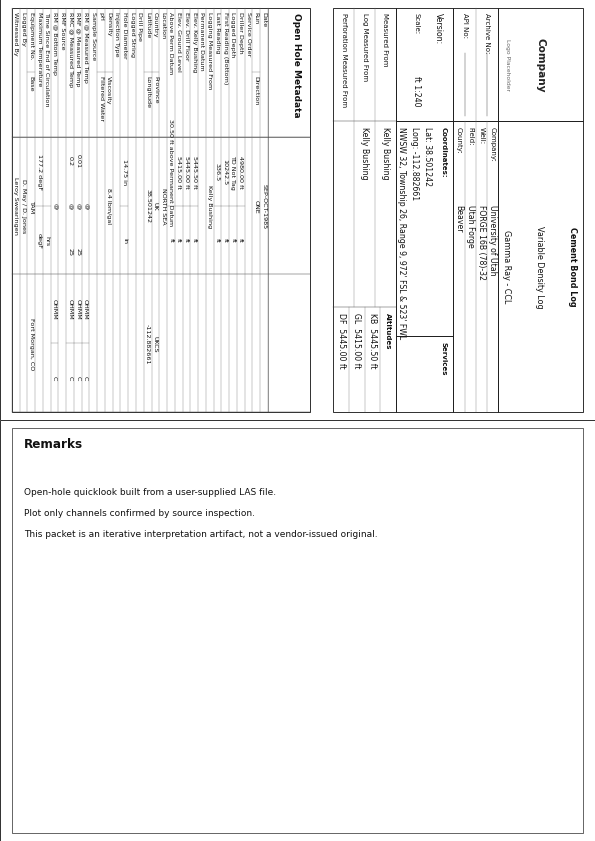

In [7]:
remarks_result = await session.revise(
    feedback="""
        Add one concise remarks block to the first page.

        - Keep it short and readable.
        - Mention that this is an open-hole quicklook built from a user-supplied LAS file.
        - Mention that only channels confirmed through the source inspection should be plotted.
        - Mention that this packet is an iterative interpretation artifact, not a vendor-issued original.
    """,
)

display_authoring_result("Remarks added", remarks_result, preview="report")

## 4. Refine The GR/SP Overview Track

Ask the model to refine the seeded overview track and to bind curves only when they actually exist in the LAS file.


GR/SP overview track
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Done:
 - Added curve bindings: main/gr_sp/SP.
 - Updated curve bindings: main/gr_sp/GR.
Next help:
 - I can help with the next draft revision or render the final PDF.
Tool trace: ['summarize_logfile_draft', 'inspect_authoring_vocab', 'bind_curve', 'set_track_scales']


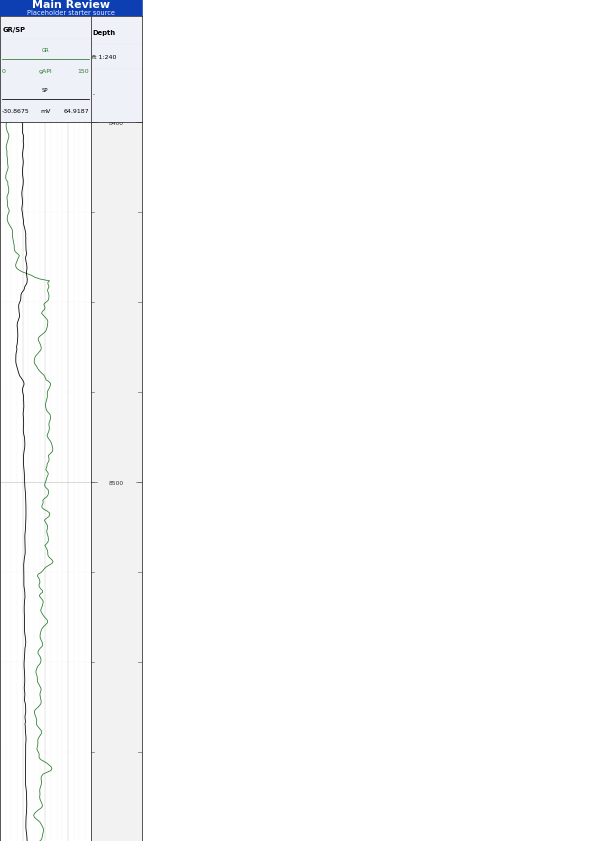

In [8]:
gr_sp_result = await session.revise(
    feedback="""
        Revise the existing draft.

        - Revise the existing `gr_sp` overview track before the depth track.
        - If both GR and SP are available, bind both to this track.
        - If SP is missing, keep a GR-only overview.
        - Use a readable green gamma-ray curve and conventional linear scaling.
    """,
)

display_authoring_result("GR/SP overview track", gr_sp_result)

## 5. Add The Resistivity Track

The next revision adds one log-scale resistivity track and prefers the deepest curve visually if several resistivity channels are available.


Resistivity track
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Done:
 - Section main: added tracks ['resistivity'].
 - Added curve bindings: main/resistivity/ILD, main/resistivity/ILM, main/resistivity/MSFL.
Next help:
 - I can help with the next draft revision or render the final PDF.
Tool trace: ['summarize_logfile_draft', 'add_track', 'move_track', 'bind_curve', 'bind_curve', 'bind_curve', 'bind_curve', 'bind_curve', 'bind_curve', 'inspect_track_bindings']


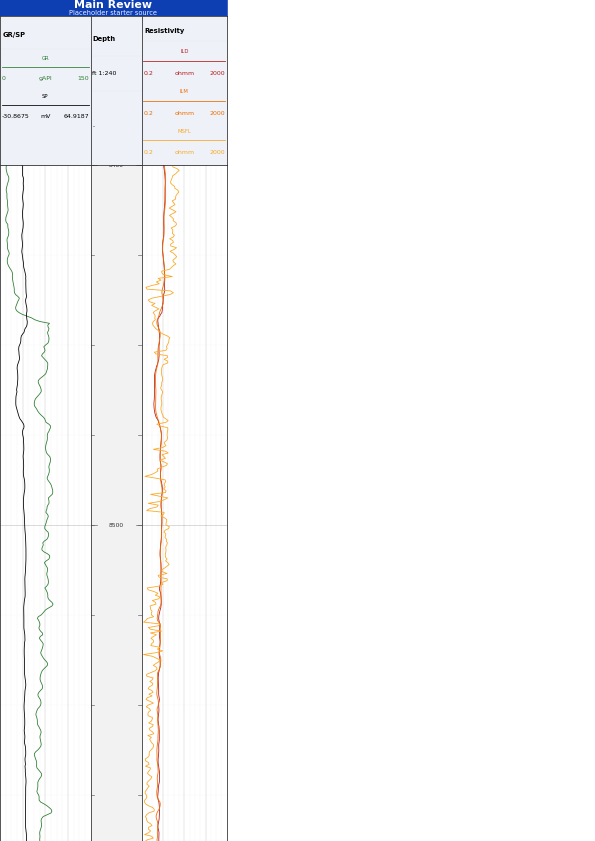

In [9]:
resistivity_result = await session.revise(
    feedback="""
        Revise the existing draft.

        - Add one resistivity track after the depth track.
        - Use a logarithmic scale from 0.2 to 2000 ohm.m.
        - Bind the deep, medium, and shallow resistivity curves that are available.
        - Keep the deepest resistivity curve visually strongest.
    """,
)

display_authoring_result("Resistivity track", resistivity_result)

## 6. Add The Porosity Overlay Track

Now add the density-neutron overlay and ask the model to create a crossover fill only when both channels are available.


Porosity overlay track
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Done:
 - Section main: added tracks ['porosity'].
 - Added curve bindings: main/porosity/NPHI, main/porosity/RHOB.
Next help:
 - I can help with the next draft revision or render the final PDF.
Tool trace: ['summarize_logfile_draft', 'check_channel_availability', 'check_channel_availability', 'add_track', 'bind_curve', 'bind_curve', 'add_curve_fill']


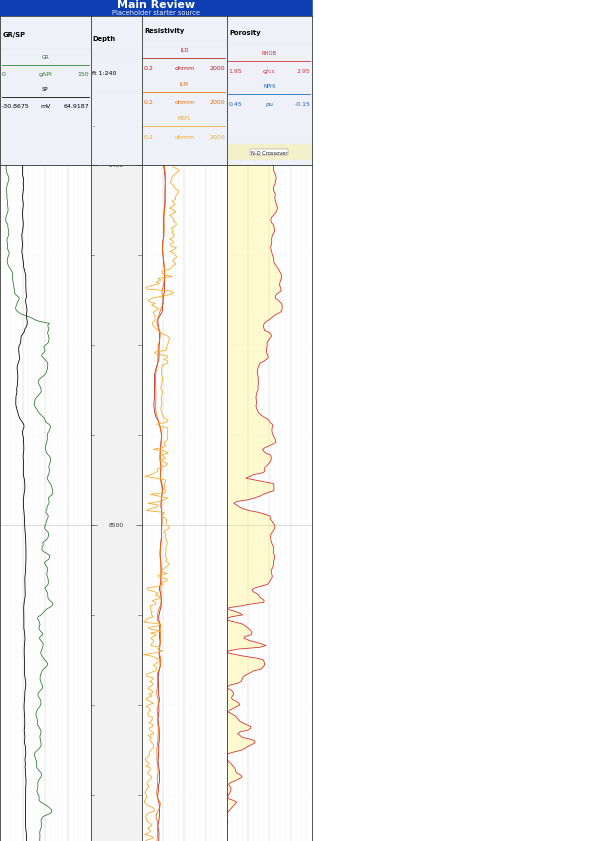

In [10]:
porosity_result = await session.revise(
    feedback="""
        Revise the existing draft.

        - Add one porosity track after the resistivity track.
        - If RHOB and NPHI are available, overlay them in the same track.
        - Reverse the neutron scale so crossover reads naturally.
        - Add a crossover fill only when both RHOB and NPHI are present.
        - For that crossover fill, prefer the between_instances pattern
          against the RHOB overlay instead of between_curves.
    """,
)

display_authoring_result("Porosity overlay track", porosity_result)

## 7. Add A Narrow QC Track

Finish the log section by adding a small QC track for supporting curves such as caliper, PEF, or DRHO when the source contains them.


QC track
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Done:
 - Section main: added tracks ['qc'].
 - Added curve bindings: main/qc/CALI, main/qc/DRHO, main/qc/PEF.
Next help:
 - I can help with the next draft revision or render the final PDF.
Tool trace: ['summarize_logfile_draft', 'check_channel_availability', 'check_channel_availability', 'add_track', 'add_track', 'bind_curve', 'bind_curve', 'bind_curve', 'bind_curve', 'inspect_track_bindings']


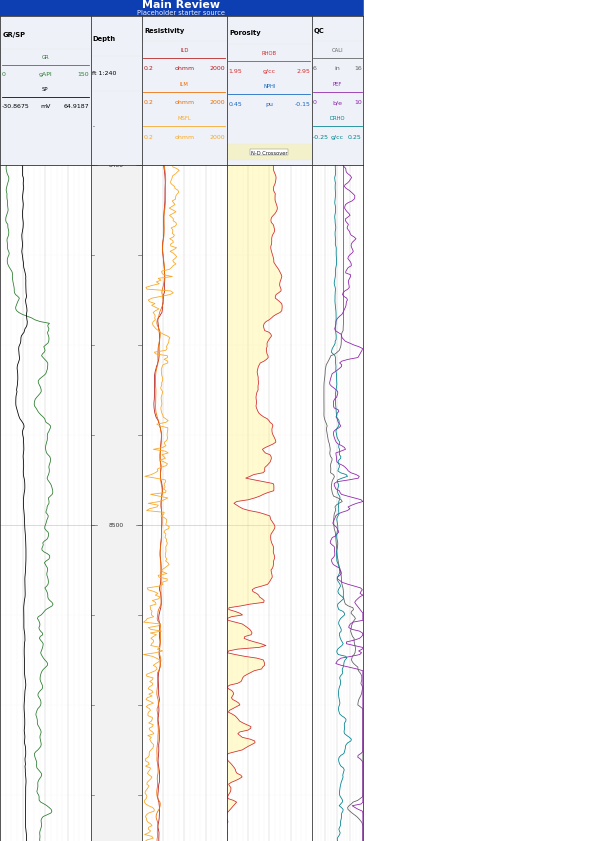

In [11]:
qc_result = await session.revise(
    feedback="""
        Revise the existing draft.

        - Add one narrow QC track after the porosity track.
        - Bind supporting curves such as CALI, PEF, and DRHO only when they are available.
        - Keep the track readable and lighter-weight than the main interpretation tracks.
    """,
)

display_authoring_result("QC track", qc_result)

QC track
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Done:
 - Updated curve bindings: main/resistivity/ILD, main/resistivity/ILM, main/resistivity/MSFL.
Next help:
 - I can help with the next draft revision or render the final PDF.
Tool trace: ['set_matplotlib_style', 'summarize_logfile_draft', 'set_track_scales']


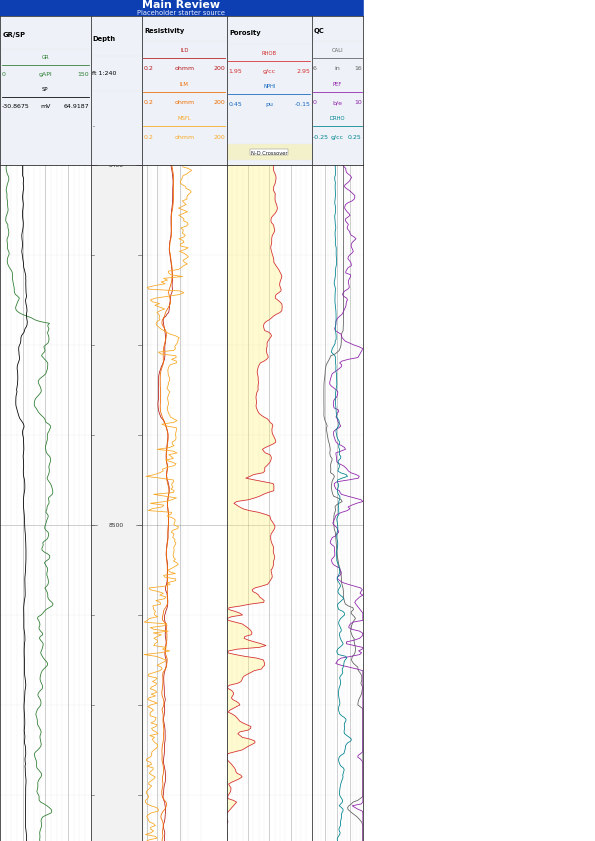

In [12]:
qc_result = await session.revise(
    feedback="""
        Revise the existing draft.
        - Make darker grid lines 
        - Change the Resistivity track scale to 0.2 to 200, along with all the curves scales in that track     
        """,
)

display_authoring_result("QC track", qc_result)

## 8. Render The Final PDF

Once the section preview looks right, render the full draft through the public agent session helper so the notebook still uses the MCP-backed path.


In [13]:
render_result = await session.render_logfile_to_file(
    overwrite=True,
)

print("Rendered PDF:", render_result["output_path"])
print("Pages:", render_result["page_count"])

Rendered PDF: /home/user/projects/well_log_os/workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.pdf
Pages: 7
